In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Cargar datos del oro
df = yf.download("GC=F", start="2020-01-01", end="2024-12-31")
df['retorno'] = df['Close'].pct_change() * 100
df['retorno_ayer'] = df['retorno'].shift(1)
df['ma7']  = df['Close'].rolling(7).mean()
df['ma21'] = df['Close'].rolling(21).mean()
df['volatilidad_7d'] = df['retorno'].rolling(7).std()
df = df.dropna()

print(f"Dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
print(df[['Close', 'retorno', 'retorno_ayer', 'ma7', 'ma21', 'volatilidad_7d']].head())

[*********************100%***********************]  1 of 1 completed

Dataset: 1237 filas, 10 columnas
Price             Close   retorno retorno_ayer          ma7         ma21  \
Ticker             GC=F                                                    
Date                                                                       
2020-01-31  1582.900024 -0.037889     0.872720  1573.985718  1559.933338   
2020-02-03  1577.199951 -0.360103    -0.037889  1575.785714  1562.442859   
2020-02-04  1550.400024 -1.699209    -0.360103  1572.828578  1562.500006   
2020-02-05  1557.800049  0.477298    -1.699209  1570.114293  1562.100010   
2020-02-06  1565.099976  0.468605     0.477298  1569.528582  1561.780959   

Price      volatilidad_7d  
Ticker                     
Date                       
2020-01-31       0.449526  
2020-02-03       0.472088  
2020-02-04       0.806435  
2020-02-05       0.820471  
2020-02-06       0.838717  


In [4]:
# Definir X (features) e y (target)
features = ['retorno_ayer', 'ma7', 'ma21', 'volatilidad_7d']
X = df[features]
y = df['retorno']  # queremos predecir el retorno de hoy

# Split temporal — los últimos 20% son test
split = int(len(df) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Train: {len(X_train)} filas ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Test:  {len(X_test)} filas ({X_test.index[0].date()} → {X_test.index[-1].date()})")
print(f"\nFeatures: {features}")
print(f"Target: retorno diario del oro")

Train: 989 filas (2020-01-31 → 2024-01-04)
Test:  248 filas (2024-01-05 → 2024-12-30)

Features: ['retorno_ayer', 'ma7', 'ma21', 'volatilidad_7d']
Target: retorno diario del oro


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir en train y test
y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

# Evaluar
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

print("=== RESULTADOS DEL MODELO ===")
print(f"\nRMSE Train: {rmse_train:.4f}%")
print(f"RMSE Test:  {rmse_test:.4f}%")
print(f"\nR² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")

print("\n=== COEFICIENTES DEL MODELO ===")
for feature, coef in zip(features, modelo.coef_):
    print(f"{feature:20s}: {coef:.6f}")
print(f"{'Intercepto':20s}: {modelo.intercept_:.6f}")

=== RESULTADOS DEL MODELO ===

RMSE Train: 1.0467%
RMSE Test:  1.0508%

R² Train: 0.0051
R² Test:  -0.2436

=== COEFICIENTES DEL MODELO ===
retorno_ayer        : -0.016731
ma7                 : -0.000136
ma21                : -0.000587
volatilidad_7d      : -0.022779
Intercepto          : 1.375709


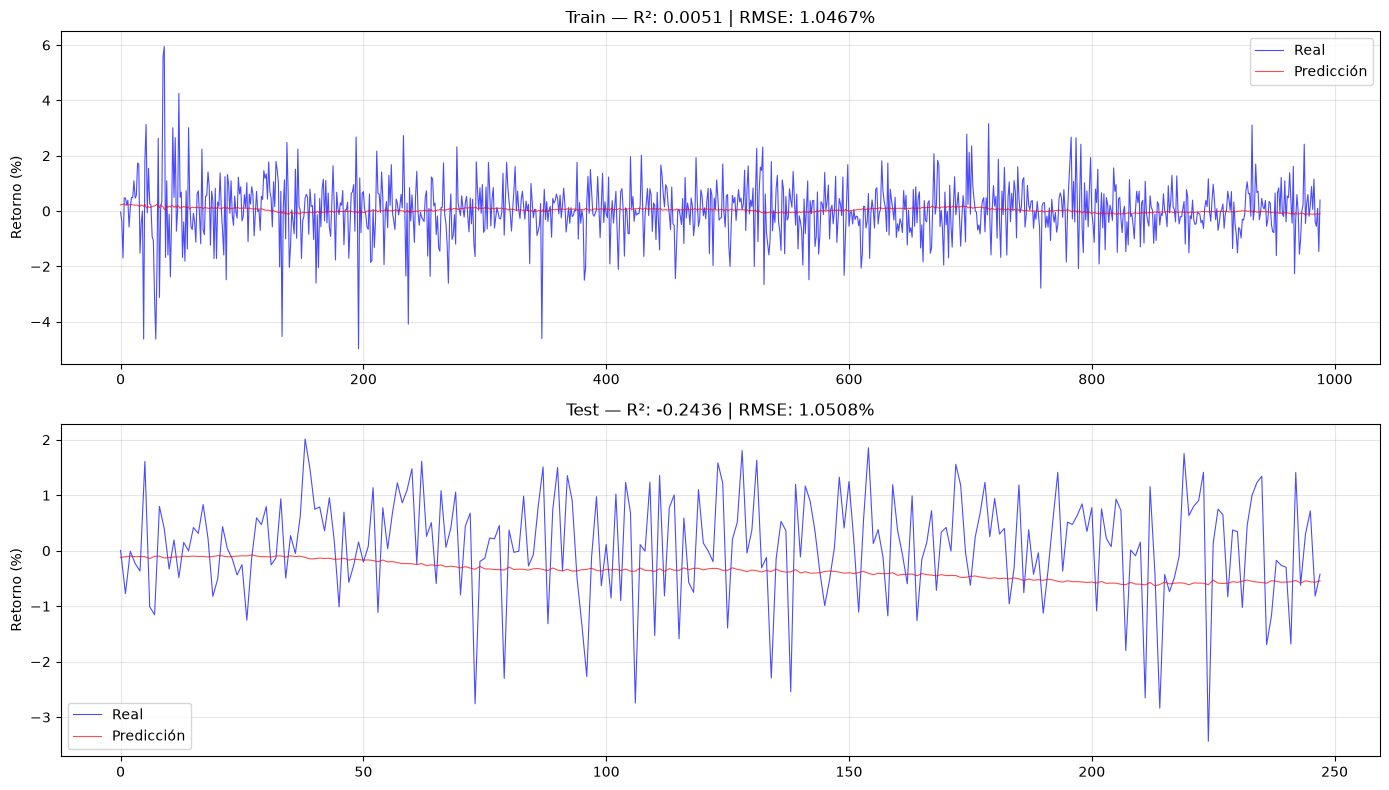

In [6]:
# Visualizar predicciones vs realidad
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1 — Train
axes[0].plot(y_train.values, color='blue', linewidth=0.8, 
             label='Real', alpha=0.7)
axes[0].plot(y_pred_train, color='red', linewidth=0.8, 
             label='Predicción', alpha=0.7)
axes[0].set_title(f'Train — R²: {r2_train:.4f} | RMSE: {rmse_train:.4f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('Retorno (%)')

# Gráfico 2 — Test
axes[1].plot(y_test.values, color='blue', linewidth=0.8, 
             label='Real', alpha=0.7)
axes[1].plot(y_pred_test, color='red', linewidth=0.8, 
             label='Predicción', alpha=0.7)
axes[1].set_title(f'Test — R²: {r2_test:.4f} | RMSE: {rmse_test:.4f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylabel('Retorno (%)')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Entrenar Random Forest
rf = RandomForestRegressor(
    n_estimators=100,    # 100 árboles
    max_depth=5,         # profundidad máxima de cada árbol
    random_state=42      # para reproducibilidad
)
rf.fit(X_train, y_train)

# Predecir
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test  = rf.predict(X_test)

# Evaluar
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test  = np.sqrt(mean_squared_error(y_test,  y_pred_rf_test))
r2_rf_train   = r2_score(y_train, y_pred_rf_train)
r2_rf_test    = r2_score(y_test,  y_pred_rf_test)

print("=== RANDOM FOREST vs REGRESIÓN LINEAL ===")
print(f"\n{'Métrica':15} {'Reg. Lineal Train':>18} {'Reg. Lineal Test':>17} {'RF Train':>10} {'RF Test':>10}")
print("-" * 75)
print(f"{'RMSE':15} {rmse_train:>18.4f}% {rmse_test:>16.4f}% {rmse_rf_train:>9.4f}% {rmse_rf_test:>9.4f}%")
print(f"{'R²':15} {r2_train:>18.4f} {r2_test:>16.4f} {r2_rf_train:>10.4f} {r2_rf_test:>10.4f}")

# Importancia de features
print("\n=== IMPORTANCIA DE FEATURES (Random Forest) ===")
for feature, imp in zip(features, rf.feature_importances_):
    barra = '█' * int(imp * 50)
    print(f"{feature:20s}: {imp:.4f} {barra}")

=== RANDOM FOREST vs REGRESIÓN LINEAL ===

Métrica          Reg. Lineal Train  Reg. Lineal Test   RF Train    RF Test
---------------------------------------------------------------------------
RMSE                        1.0467%           1.0508%    0.9231%    0.9322%
R²                          0.0051          -0.2436     0.2263     0.0212

=== IMPORTANCIA DE FEATURES (Random Forest) ===
retorno_ayer        : 0.1835 █████████
ma7                 : 0.2125 ██████████
ma21                : 0.1582 ███████
volatilidad_7d      : 0.4458 ██████████████████████


In [8]:
from sklearn.ensemble import RandomForestRegressor

# Entrenar Random Forest
rf = RandomForestRegressor(
    n_estimators=100,    # 100 árboles
    max_depth=3,         # profundidad máxima de cada árbol
    random_state=42      # para reproducibilidad
)
rf.fit(X_train, y_train)

# Predecir
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test  = rf.predict(X_test)

# Evaluar
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test  = np.sqrt(mean_squared_error(y_test,  y_pred_rf_test))
r2_rf_train   = r2_score(y_train, y_pred_rf_train)
r2_rf_test    = r2_score(y_test,  y_pred_rf_test)

print("=== RANDOM FOREST vs REGRESIÓN LINEAL ===")
print(f"\n{'Métrica':15} {'Reg. Lineal Train':>18} {'Reg. Lineal Test':>17} {'RF Train':>10} {'RF Test':>10}")
print("-" * 75)
print(f"{'RMSE':15} {rmse_train:>18.4f}% {rmse_test:>16.4f}% {rmse_rf_train:>9.4f}% {rmse_rf_test:>9.4f}%")
print(f"{'R²':15} {r2_train:>18.4f} {r2_test:>16.4f} {r2_rf_train:>10.4f} {r2_rf_test:>10.4f}")

# Importancia de features
print("\n=== IMPORTANCIA DE FEATURES (Random Forest) ===")
for feature, imp in zip(features, rf.feature_importances_):
    barra = '█' * int(imp * 50)
    print(f"{feature:20s}: {imp:.4f} {barra}")

=== RANDOM FOREST vs REGRESIÓN LINEAL ===

Métrica          Reg. Lineal Train  Reg. Lineal Test   RF Train    RF Test
---------------------------------------------------------------------------
RMSE                        1.0467%           1.0508%    0.9874%    0.9448%
R²                          0.0051          -0.2436     0.1147    -0.0053

=== IMPORTANCIA DE FEATURES (Random Forest) ===
retorno_ayer        : 0.1583 ███████
ma7                 : 0.2271 ███████████
ma21                : 0.1086 █████
volatilidad_7d      : 0.5061 █████████████████████████


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Entrenar Random Forest
rf = RandomForestRegressor(
    n_estimators=100,    # 100 árboles
    max_depth=4,         # profundidad máxima de cada árbol
    random_state=42      # para reproducibilidad
)
rf.fit(X_train, y_train)

# Predecir
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test  = rf.predict(X_test)

# Evaluar
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_rf_test  = np.sqrt(mean_squared_error(y_test,  y_pred_rf_test))
r2_rf_train   = r2_score(y_train, y_pred_rf_train)
r2_rf_test    = r2_score(y_test,  y_pred_rf_test)

print("=== RANDOM FOREST vs REGRESIÓN LINEAL ===")
print(f"\n{'Métrica':15} {'Reg. Lineal Train':>18} {'Reg. Lineal Test':>17} {'RF Train':>10} {'RF Test':>10}")
print("-" * 75)
print(f"{'RMSE':15} {rmse_train:>18.4f}% {rmse_test:>16.4f}% {rmse_rf_train:>9.4f}% {rmse_rf_test:>9.4f}%")
print(f"{'R²':15} {r2_train:>18.4f} {r2_test:>16.4f} {r2_rf_train:>10.4f} {r2_rf_test:>10.4f}")

# Importancia de features
print("\n=== IMPORTANCIA DE FEATURES (Random Forest) ===")
for feature, imp in zip(features, rf.feature_importances_):
    barra = '█' * int(imp * 50)
    print(f"{feature:20s}: {imp:.4f} {barra}")

=== RANDOM FOREST vs REGRESIÓN LINEAL ===

Métrica          Reg. Lineal Train  Reg. Lineal Test   RF Train    RF Test
---------------------------------------------------------------------------
RMSE                        1.0467%           1.0508%    0.9575%    0.9450%
R²                          0.0051          -0.2436     0.1676    -0.0057

=== IMPORTANCIA DE FEATURES (Random Forest) ===
retorno_ayer        : 0.1723 ████████
ma7                 : 0.2209 ███████████
ma21                : 0.1396 ██████
volatilidad_7d      : 0.4672 ███████████████████████


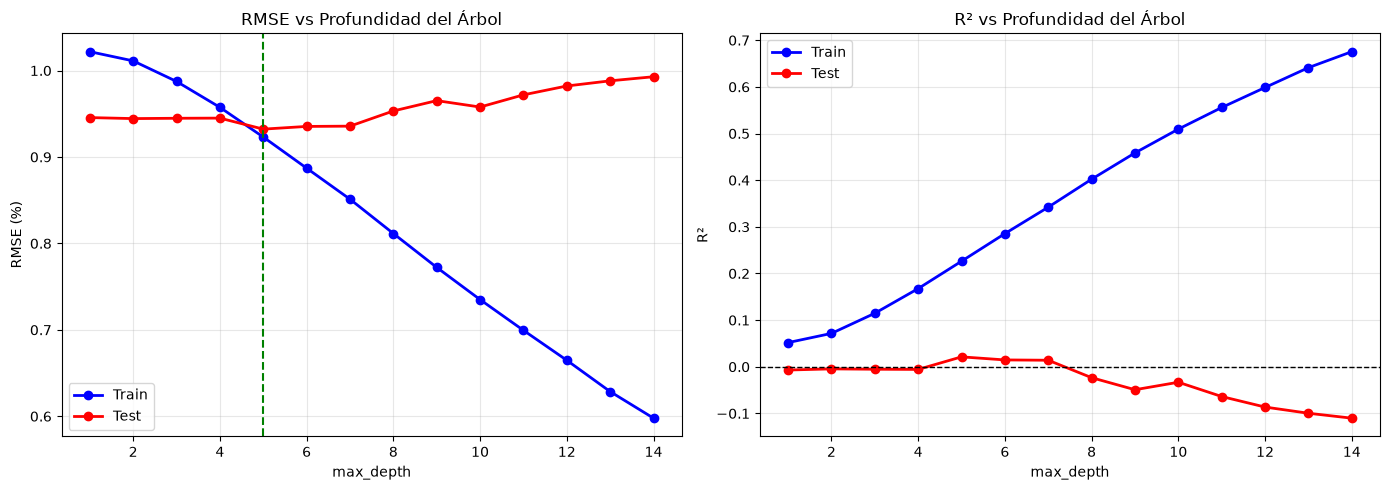

Mejor max_depth para test: 5
R² test en ese punto: 0.0212


In [10]:
# Visualizar bias-variance tradeoff
depths = range(1, 15)
rmse_trains = []
rmse_tests  = []
r2_trains   = []
r2_tests    = []

for depth in depths:
    rf_temp = RandomForestRegressor(
        n_estimators=100, 
        max_depth=depth, 
        random_state=42
    )
    rf_temp.fit(X_train, y_train)
    
    y_tr = rf_temp.predict(X_train)
    y_te = rf_temp.predict(X_test)
    
    rmse_trains.append(np.sqrt(mean_squared_error(y_train, y_tr)))
    rmse_tests.append(np.sqrt(mean_squared_error(y_test, y_te)))
    r2_trains.append(r2_score(y_train, y_tr))
    r2_tests.append(r2_score(y_test, y_te))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].plot(depths, rmse_trains, 'b-o', label='Train', linewidth=2)
axes[0].plot(depths, rmse_tests,  'r-o', label='Test',  linewidth=2)
axes[0].set_title('RMSE vs Profundidad del Árbol')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('RMSE (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=5, color='green', linestyle='--', label='depth=5')

# R²
axes[1].plot(depths, r2_trains, 'b-o', label='Train', linewidth=2)
axes[1].plot(depths, r2_tests,  'r-o', label='Test',  linewidth=2)
axes[1].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('R² vs Profundidad del Árbol')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar el mejor depth para test
mejor_depth = depths[r2_tests.index(max(r2_tests))]
print(f"Mejor max_depth para test: {mejor_depth}")
print(f"R² test en ese punto: {max(r2_tests):.4f}")